In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x: .3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)
RANDOM_STATE = 42
DATASET_PATH = "../data/Online Retail.csv"

In [ ]:
df = pd.read_csv(DATASET_PATH)

In [57]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550,17850.000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750,17850.000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390,17850.000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390,17850.000,United Kingdom


In [58]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [59]:
df.shape

(541909, 8)

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [61]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000,541909.000,406829.000
mean,9.552,4.611,15287.691
std,218.081,96.760,1713.600
min,-80995.000,-11062.060,12346.000
25%,1.000,1.250,13953.000
50%,3.000,2.080,15152.000
75%,10.000,4.130,16791.000
max,80995.000,38970.000,18287.000


In [ ]:
df = df.dropna(subset=["CustomerID"])
print("Shape of dataset:", df.shape)

Shape of dataset: (406829, 8)


In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  str    
 1   StockCode    406829 non-null  str    
 2   Description  406829 non-null  str    
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  str    
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 27.9 MB


In [ ]:
# To check if there are cancllations and returns and drop that column

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [ ]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [66]:
print("Shape of dataset:", df.shape)

Shape of dataset: (397884, 8)


In [74]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

snapshot_data = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_data - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.000,326,1,77183.600
1,12347.000,2,7,4310.000
2,12348.000,75,4,1797.240
3,12349.000,19,1,1757.550
4,12350.000,310,1,334.400


In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [77]:
rfm_log=rfm.copy()
rfm_log['Frequency']=np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']=np.log1p(rfm_log['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency','Frequency','Monetary']])

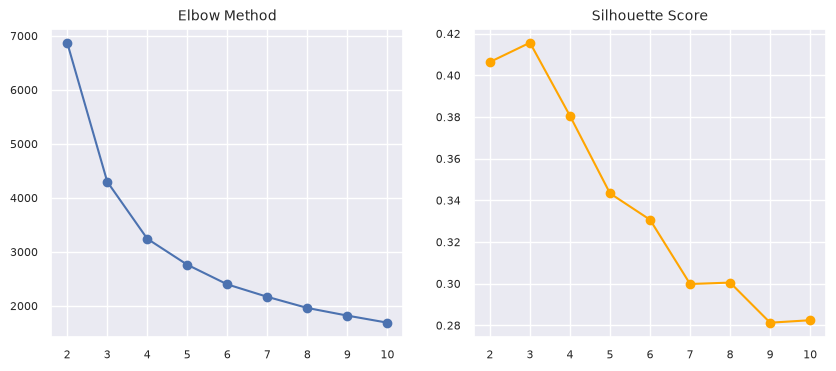

In [80]:
inertias =[]
silhouette= []

k_range = range(2,11)

for k in k_range:
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    labels =km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled,labels))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(k_range, inertias, marker='o')
ax[0].set_title('Elbow Method')

ax[1].plot(k_range, silhouette, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
plt.show()

In [81]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Count'] = rfm['Cluster'].value_counts()
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,54.900,2.000,615.200,2036
1,30.100,9.800,5494.300,1323
2,255.300,1.400,398.100,979
